In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

In [9]:
import os
import cv2
import numpy as np
import tifffile
from tqdm import tqdm

def merge_with_mask(img_path, mask_path):
    """
    Merge RGB image and mask into a 4-channel array.
    """
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)      # (H,W,3)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # (H,W)

    if img is None or mask is None:
        raise ValueError(f"Missing file: {img_path} or {mask_path}")

    # Resize mask if needed
    if img.shape[:2] != mask.shape[:2]:
        print("The mask has a different shape from the image!!!")
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), cv2.INTER_NEAREST)

    # Expand mask to (H,W,1)
    mask = np.expand_dims(mask, axis=-1)

    # Merge → (H,W,4)
    merged = np.concatenate([img, mask], axis=-1)
    return merged

def merge_all_images(img_dir, mask_dir, out_dir="merged_tiff_dataset"):
    """
    Merge all images and masks in the specified folders.
    """
    os.makedirs(out_dir, exist_ok=True)
    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(".png")])

    for f in tqdm(img_files, desc="Merging images with masks"):
        img_path = os.path.join(img_dir, f)
        
        # Extract the numeric index
        index = f.replace("image_", "").replace(".png", "")
        mask_filename = f"mask_{index}.png"
        mask_path = os.path.join(mask_dir, mask_filename)
    
        if not os.path.exists(mask_path):
            print(f"⚠️ Mask missing for {f}, expected {mask_filename}, skipping")
            continue
    
        merged = merge_with_mask(img_path, mask_path)
    
        out_path = os.path.join(out_dir, f.replace(".png", ".tiff"))
        tifffile.imwrite(out_path, merged)


    print(f"Merged {len(img_files)} images saved in {out_dir}")
    return out_dir

In [4]:
import zipfile

def zip_merged_dataset(merged_dir, zip_name="final_merged_dataset.zip"):
    """
    Compress all merged TIFF files into a ZIP.
    """
    with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
        for f in os.listdir(merged_dir):
            full_path = os.path.join(merged_dir, f)
            zipf.write(full_path, arcname=f)
    print(f"ZIP created: {zip_name}")
    return zip_name


# MAIN

## Train images

In [14]:
import os
from tqdm import tqdm
import shutil

# Assuming merge_all_images and zip_merged_dataset are already defined
# as in the previous step

if __name__ == "__main__":
    base_dir = "../input/final-clean-dataset/final_clean_dataset"
    img_dir = os.path.join(base_dir, "images")
    mask_dir = os.path.join(base_dir, "masks")

    # Step 1: Merge RGB images with masks into 4-channel TIFFs
    print("🔹 Step 1: Merging images and masks into TIFFs...")
    merged_dir = merge_all_images(img_dir, mask_dir, out_dir="train_data_submission/train_data_merged")


🔹 Step 1: Merging images and masks into TIFFs...


Merging images with masks: 100%|██████████| 1239/1239 [01:27<00:00, 14.22it/s]

Merged 1239 images saved in train_data_submission/train_data_merged


In [15]:

    # Original labels CSV
    labels_csv = os.path.join(base_dir, "train_labels.csv")    
    
    # Destination: same folder as merged TIFFs
    shutil.copy(labels_csv, "train_data_submission/train_data_merged/train_label.csv")
    print("✅ Labels CSV copied to merged directory.")



✅ Labels CSV copied to merged directory.


In [17]:
    # Step 2: Create a ZIP of merged dataset for download
    print("🔹 Step 2: Creating ZIP file for download...")
    # Usage
    zip_path = zip_merged_dataset("train_data_submission/train_data_merged",
                                       zip_name="train_data_submission/final_merged_dataset.zip")
    print("All done!")
    print(f"Merged dataset ZIP ready: {zip_path}")

🔹 Step 2: Creating ZIP file for download...
ZIP created: train_data_submission/final_merged_dataset.zip
All done!
Merged dataset ZIP ready: train_data_submission/final_merged_dataset.zip


In [20]:
from IPython.display import FileLink
FileLink("train_data_submission/final_merged_dataset.zip")


/kaggle/working/train_data_submission/final_merged_dataset.zip

## Test images

In [ ]:
import os
from tqdm import tqdm
import shutil

# Assuming merge_all_images and zip_merged_dataset are already defined
# as in the previous step

if __name__ == "__main__":
    base_dir = "../input" #ADD YOUR INPUT FILE PATH HERE
    img_dir = os.path.join(base_dir, "images")
    mask_dir = os.path.join(base_dir, "masks")

    # Step 1: Merge RGB images with masks into 4-channel TIFFs
    print("🔹 Step 1: Merging images and masks into TIFFs...")

    #dont change this name
    merged_dir = merge_all_images(img_dir, mask_dir, out_dir="train_data_submission/train_data_merged")


In [ ]:
    # Step 2: Create a ZIP of merged dataset for download
    print("🔹 Step 2: Creating ZIP file for download...")
    #CHANGE THE OUTPUT NAME HERE
    zip_path = zip_merged_dataset("train_data_submission/train_data_merged",
                                       zip_name="train_data_submission/final_merged_dataset.zip")
    print("All done!")
    print(f"Merged dataset ZIP ready: {zip_path}")

# Secondary content. not important.


In [5]:
def sanity_check(merged_dir, n_samples=5):
    """
    Display RGB image + mask for a few samples from merged TIFF dataset.
    """
    merged_files = sorted([f for f in os.listdir(merged_dir) if f.endswith(".tiff")])
    sampled_files = random.sample(merged_files, min(n_samples, len(merged_files)))

    for f in sampled_files:
        path = os.path.join(merged_dir, f)
        merged = tifffile.imread(path)  # H,W,4

        rgb = merged[..., :3]
        mask = merged[..., 3]

        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(rgb)
        plt.title(f"RGB: {f}")
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.imshow(mask, cmap='gray')
        plt.title("Mask")
        plt.axis('off')

        plt.show()


🔹 Step 1: Merging images and masks into TIFFs...


Merging images with masks: 100%|██████████| 1239/1239 [01:42<00:00, 12.09it/s]


Merged 1239 images saved in train_data_submission/train_data_merged
🔹 Step 1b: Sanity check of merged images...


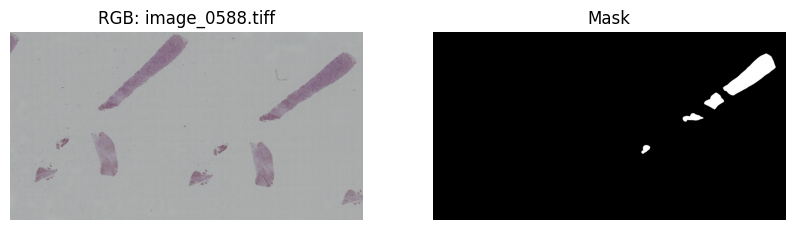

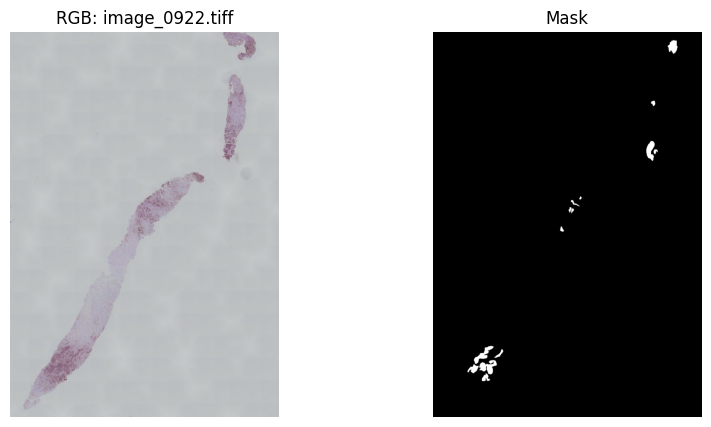

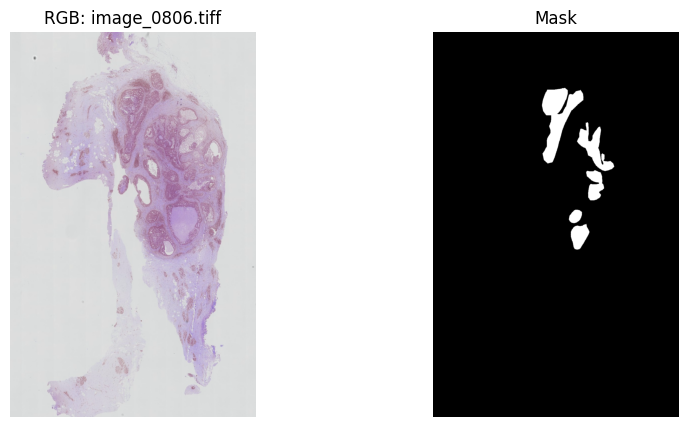

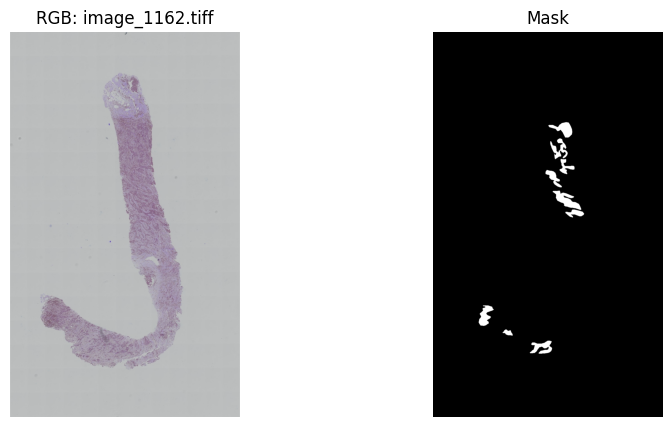

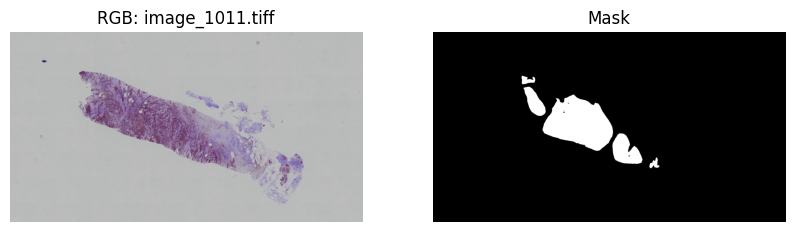

In [10]:
import os
import random
import matplotlib.pyplot as plt
import tifffile
from tqdm import tqdm

base_dir = "../input/final-clean-dataset/final_clean_dataset"
img_dir = os.path.join(base_dir, "images")
mask_dir = os.path.join(base_dir, "masks")

    # Step 1: Merge RGB images with masks into 4-channel TIFFs
print("🔹 Step 1: Merging images and masks into TIFFs...")
merged_dir = merge_all_images(img_dir, mask_dir, out_dir="train_data_submission/train_data_merged")
    

print("🔹 Step 1b: Sanity check of merged images...")
sanity_check(merged_dir, n_samples=5)